# Web Logs Visualization

Визуализация результатов анализа логов из Hive.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('../visualization/data')
CHARTS_DIR = Path('../visualization/charts')
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (10, 5)

## 1. Распределение HTTP-кодов

,status_code,requests_count
0,200,31
1,201,40
2,401,38
3,403,31
4,404,29
5,500,45


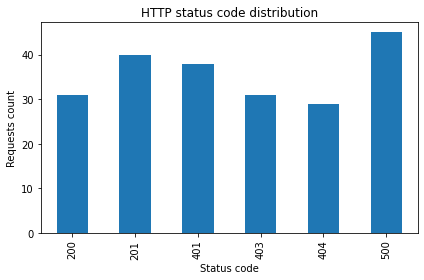

In [2]:
status_df = pd.read_csv(DATA_DIR / 'status_counts.tsv', sep='\t', names=['status_code', 'requests_count'])
display(status_df)

status_df.plot(kind='bar', x='status_code', y='requests_count', legend=False)
plt.title('HTTP status code distribution')
plt.xlabel('Status code')
plt.ylabel('Requests count')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'status_counts.png')
plt.show()

## 2. Топ URL

,url,requests_count
0,/api/users,82
1,/api/orders,69
2,/api/login,63


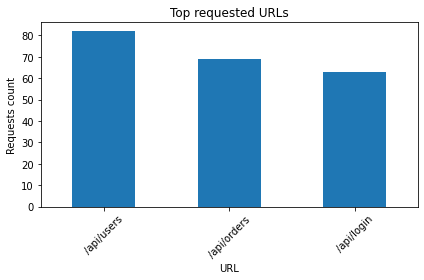

In [3]:
url_df = pd.read_csv(DATA_DIR / 'url_counts.tsv', sep='\t', names=['url', 'requests_count'])
display(url_df)

url_df.plot(kind='bar', x='url', y='requests_count', legend=False)
plt.title('Top requested URLs')
plt.xlabel('URL')
plt.ylabel('Requests count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'url_counts.png')
plt.show()

## 3. Топ IP-адресов

,ip,requests_count
0,192.168.1.11,78
1,192.168.1.10,71
2,192.168.1.12,65


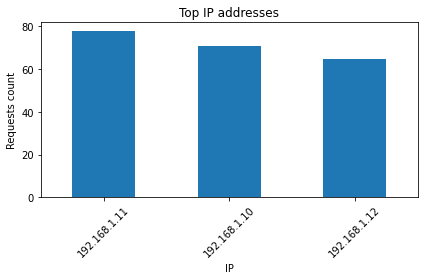

In [4]:
ip_df = pd.read_csv(DATA_DIR / 'ip_counts.tsv', sep='\t', names=['ip', 'requests_count'])
display(ip_df)

ip_df.plot(kind='bar', x='ip', y='requests_count', legend=False)
plt.title('Top IP addresses')
plt.xlabel('IP')
plt.ylabel('Requests count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'ip_counts.png')
plt.show()

## 4. Распределение HTTP-методов

,method,requests_count
0,POST,65
1,GET,59
2,DELETE,55
3,PUT,35


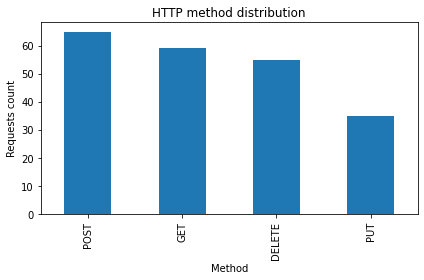

In [5]:
method_df = pd.read_csv(DATA_DIR / 'method_counts.tsv', sep='\t', names=['method', 'requests_count'])
display(method_df)

method_df.plot(kind='bar', x='method', y='requests_count', legend=False)
plt.title('HTTP method distribution')
plt.xlabel('Method')
plt.ylabel('Requests count')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'method_counts.png')
plt.show()

## 5. Количество запросов по минутам

,minute_window,requests_count
0,2026-05-25 22:05:00,1
1,2026-05-25 22:06:00,1
2,2026-05-25 22:07:00,1
3,2026-05-25 22:41:00,48
4,2026-05-25 22:42:00,5
5,2026-05-25 22:47:00,24
6,2026-05-25 22:48:00,30
7,2026-05-27 20:08:00,39
8,2026-05-27 20:09:00,60
9,2026-05-27 20:10:00,5


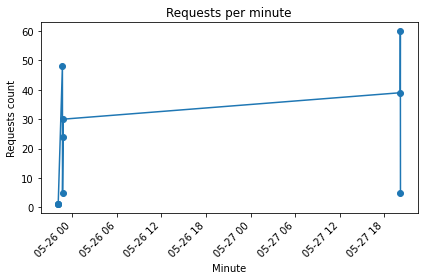

In [6]:
minute_requests_df = pd.read_csv(DATA_DIR / 'minute_requests.tsv', sep='\t', names=['minute_window', 'requests_count'])
minute_requests_df['minute_window'] = pd.to_datetime(minute_requests_df['minute_window'])
display(minute_requests_df)

minute_requests_df.plot(kind='line', x='minute_window', y='requests_count', marker='o', legend=False)
plt.title('Requests per minute')
plt.xlabel('Minute')
plt.ylabel('Requests count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'minute_requests.png')
plt.show()

## 6. Ошибки 4xx/5xx по минутам

,minute_window,client_errors_4xx,server_errors_5xx
0,2026-05-25 22:05:00,0,0
1,2026-05-25 22:06:00,1,0
2,2026-05-25 22:07:00,0,1
3,2026-05-25 22:41:00,19,9
4,2026-05-25 22:42:00,5,0
5,2026-05-25 22:47:00,12,2
6,2026-05-25 22:48:00,10,12
7,2026-05-27 20:08:00,17,8
8,2026-05-27 20:09:00,30,13
9,2026-05-27 20:10:00,4,0


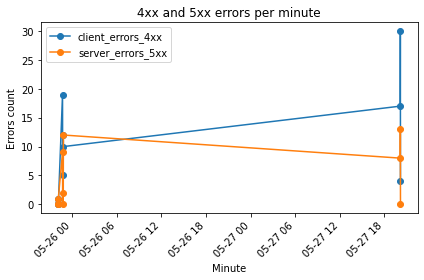

In [7]:
minute_errors_df = pd.read_csv(DATA_DIR / 'minute_errors.tsv', sep='\t', names=['minute_window', 'client_errors_4xx', 'server_errors_5xx'])
minute_errors_df['minute_window'] = pd.to_datetime(minute_errors_df['minute_window'])
display(minute_errors_df)

minute_errors_df.plot(kind='line', x='minute_window', y=['client_errors_4xx', 'server_errors_5xx'], marker='o')
plt.title('4xx and 5xx errors per minute')
plt.xlabel('Minute')
plt.ylabel('Errors count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'minute_errors.png')
plt.show()